## Task Description
Given $ k \geq 100 $ normally distributed $d$-dimensional $ (d \geq 10k) $ random variables $ X_1, X_2, ..., X_k $
select $m \in [0.1 \cdot k, 0.2 \cdot k]$ of them and define $$ Y = \beta_{i_1} X_{i_1} + \ldots + \beta_{i_m} X_{i_m} + \epsilon $$
, where $ \epsilon \in \mathcal{N}(0,1) $

Fit a linear regression model with $ L_1 $ penalty using:
 - subgradient descent
 - proximal gradient descent (ISTA)
 - proximal gradient descent with momentum (FISTA)

Plot the values of MSE at each step.

In [134]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
k = 100  # number of variables
d = 1000  # number of dimensions
m = np.random.randint(10, 20)  # number of non-zero coefficients

# X = (X_1, X_2, ..., X_k), where X_i = (x_1i, x_2i, ..., x_di)
X = np.random.randn(d, k)

# beta = vector of coefficients where k of them are non-zero
beta = np.zeros(k)
active_indices = np.random.choice(k, m, replace=False)
beta[active_indices] = np.random.randn(m)

# noise
noise_level = 0.5
epsilon = np.random.randn(d) * noise_level

# Y as defined in Task Description
Y = X.dot(beta) + epsilon

In [135]:
# helper functions

def mse(X, Y, beta):
    """Compute mean squared error (MSE)."""
    residuals = Y - X.dot(beta)
    return np.mean(residuals**2)

def mse_gradient(X, Y, beta):
    """Compute gradient of MSE with respect to beta."""
    d = X.shape[0]
    residuals = X.dot(beta) - Y
    return X.T.dot(residuals) / d

def soft_treshold(x, treshold):
    """Apply soft-thresholding operator"""
    return np.sign(x) * np.maximum(np.abs(x) - treshold, 0)

### Subgradient Descent for LASSO
**Update Rule:**
$$\beta \leftarrow \beta - \eta (\nabla \text{MSE} + \lambda \cdot \text{sign}(\beta))$$

Since the L1 penalty is non-differentiable at $\beta_i = 0$, the code uses $\lambda \cdot \text{sign}(\beta)$ as a subgradient.

In [136]:
def subgradient_descent(X, Y, eta, lam, iterations):
    _, k = X.shape
    beta = np.zeros(k)
    mse_history = []

    for _ in range(iterations):
        grad_mse = mse_gradient(X, Y, beta)
        subgrad_l1 = lam * np.sign(beta)
        beta = beta - eta * (grad_mse + subgrad_l1)
        mse_history.append(mse(X, Y, beta))
    
    return beta, mse_history

### ISTA (Iterative Shrinkage-Thresholding Algorithm)

**Update Rule:**
$$\beta^{(t+1)} = S_{\eta\lambda}(\beta^{(t)} - \eta \nabla \text{MSE})$$
*where $S$ is the soft-thresholding operator and $\eta$ is the learning rate.*

In [137]:
def ista(X, Y, eta, lam, iterations):
    k = X.shape[1]
    beta = np.zeros(k)
    mse_history = []

    for _ in range(iterations):
        grad = mse_gradient(X, Y, beta)
        beta_temp = beta - eta * grad
        beta = soft_treshold(beta_temp, eta * lam)
        mse_history.append(mse(X, Y, beta))
    
    return beta, mse_history

### FISTA (Fast Iterative Shrinkage-Thresholding Algorithm)
**Update Rules:**
1. **Momentum**: $y = \beta^{(t)} + \left( \frac{t_k - 1}{t_{k+1}} \right) (\beta^{(t)} - \beta^{(t-1)})$
2. **Proximal Step**: $\beta^{(t+1)} = S_{\eta\lambda}(y - \eta \nabla \text{MSE}(y))$
3. **Adaptive Scaling**: $t_{k+1} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}$

In [138]:
def fista(X, Y, eta, lam, iterations):
    k = X.shape[1]
    beta = np.zeros(k)
    mse_history = []
    beta_prev = np.zeros(k)
    t = 1

    for _ in range(iterations):
        beta_momentum = beta + ((t-1) / (t+1)) * (beta - beta_prev)
        grad = mse_gradient(X, Y, beta_momentum)
        beta_temp = beta_momentum - eta * grad
        beta_new = soft_treshold(beta_temp, eta * lam)
        beta_prev = beta.copy()
        beta = beta_new
        t = (1 + np.sqrt(1 + 4 * t**2)) / 2
        mse_history.append(mse(X, Y, beta))

    return beta, mse_history

In [143]:
# taking optimal learning_rate
cov_matrix = X.T.dot(X) / d
L = np.max(np.linalg.eigvals(cov_matrix))  # L = Lipshitz constant
learning_rate = 1 / L

iterations = 20  # number of iterations
lam = 0.1  # lambda determines how sparse the model is

In [144]:
beta_hat_sub, mse_sub = subgradient_descent(X, Y, learning_rate, lam, iterations)
beta_hat_ista, mse_ista = ista(X, Y, learning_rate, lam, iterations)
beta_hat_fista, mse_fista = fista(X, Y, learning_rate, lam, iterations)

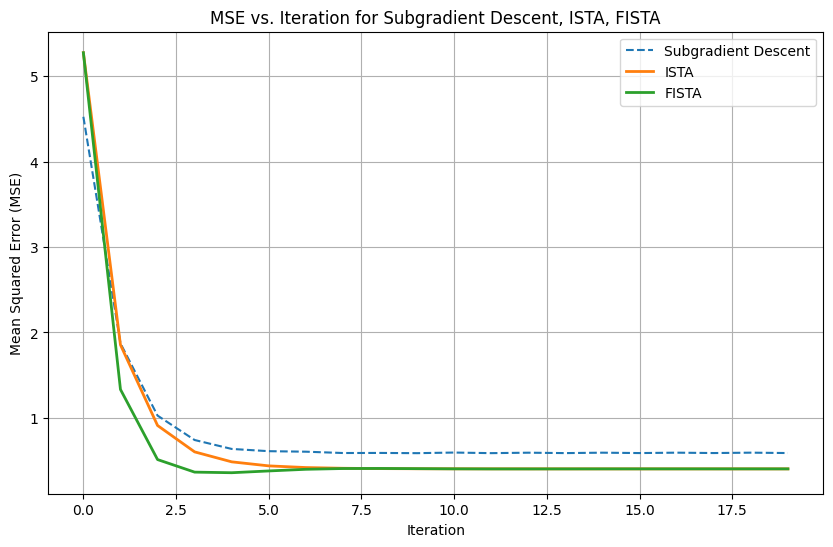

In [147]:
plt.figure(figsize=(10, 6))

plt.plot(mse_sub, label='Subgradient Descent', linestyle='--')
plt.plot(mse_ista, label='ISTA', linewidth=2)
plt.plot(mse_fista, label='FISTA', linewidth=2)
plt.title("MSE vs. Iteration for Subgradient Descent, ISTA, FISTA")
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

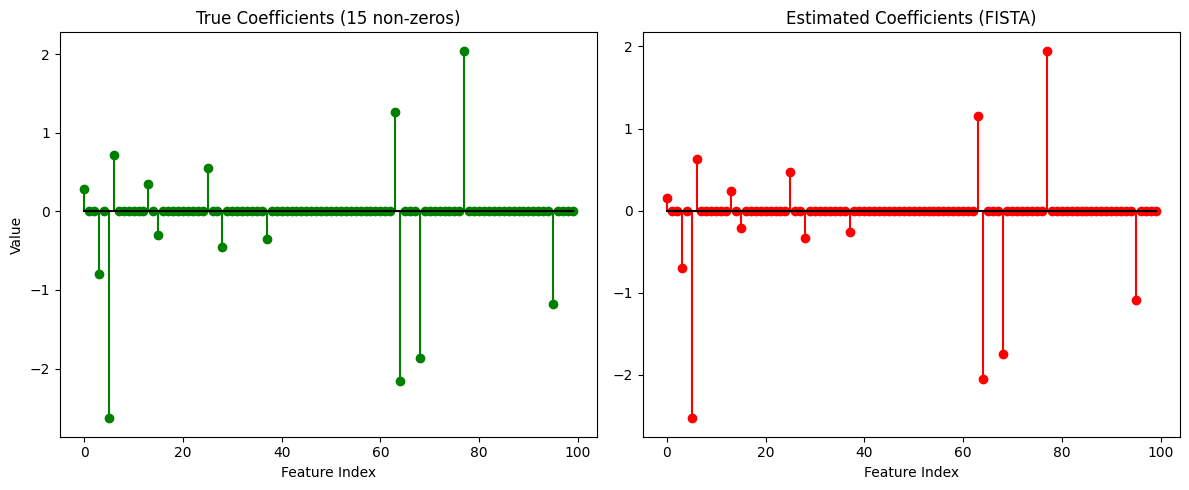

Original active features: 15
Features selected by FISTA: 14


In [148]:
# Compare beta vs beta_hat (from FISTA)
plt.figure(figsize=(12, 5))

# Plot beta Coefficients
plt.subplot(1, 2, 1)
plt.stem(beta, linefmt='g-', markerfmt='go', basefmt='k-')
plt.title(f'True Coefficients ({m} non-zeros)')
plt.xlabel('Feature Index')
plt.ylabel('Value')

# Plot beta_hat Coefficients (FISTA)
plt.subplot(1, 2, 2)
plt.stem(beta_hat_fista, linefmt='r-', markerfmt='ro', basefmt='k-')
plt.title(f'Estimated Coefficients (FISTA)')
plt.xlabel('Feature Index')

plt.tight_layout()
plt.show()

# Count non-zeros (using a small threshold for numerical stability)
non_zeros = np.sum(np.abs(beta_hat_fista) > 1e-4)
print(f"Original active features: {m}")
print(f"Features selected by FISTA: {non_zeros}")